<a href="https://colab.research.google.com/github/Lorichag/DL_Project/blob/main/Projet_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Partie 1 — Recherche, compréhension et préparation des données

## Importation du dataset:

### A partir des fichiers .zip

In [54]:
"""
import zipfile

zip_path = "train.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")
"""

'\nimport zipfile\n\nzip_path = "train.zip"\n\nwith zipfile.ZipFile(zip_path, \'r\') as zip_ref:\n    zip_ref.extractall("/content/dataset")\n'

In [55]:
"""
zip_path = "test.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")
"""

'\nzip_path = "test.zip"\n\nwith zipfile.ZipFile(zip_path, \'r\') as zip_ref:\n    zip_ref.extractall("/content/dataset")\n'

### A partir de l'API Kaggle

In [56]:
!pip install -q kaggle

In [57]:
!pip install -q --upgrade kaggle

In [58]:
!kaggle --version

Kaggle CLI 2.2.4


In [59]:
from getpass import getpass
import os

os.environ["KAGGLE_API_TOKEN"] = getpass("Entre ton token Kaggle : ")

Entre ton token Kaggle : ··········


In [60]:
!kaggle datasets download -d aadityasinghal/facial-expression-dataset

Dataset URL: https://www.kaggle.com/datasets/aadityasinghal/facial-expression-dataset
License(s): DbCL-1.0
facial-expression-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [61]:
!unzip -q facial-expression-dataset.zip -d /content/dataset

replace /content/dataset/test/test/angry/PrivateTest_10131363.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


## Création des données de train et de test

In [62]:
import os

print(os.listdir("/content/dataset"))

['train', 'test', '.ipynb_checkpoints']


In [63]:
import tensorflow as tf

train_dir = "/content/dataset/train/train"
test_dir = "/content/dataset/test/test"

classes = sorted(os.listdir(train_dir))

print("Classes :", classes)

Classes : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


## Description du Datasets :  

In [64]:
print("Nombre d'images par classe - TRAIN\n")

nb_images_total=0
for emotion in classes:
    path = os.path.join(train_dir, emotion)
    nb_images = len(os.listdir(path))
    nb_images_total+=nb_images
    print(f"{emotion:10s} : {nb_images}")

print(f"\nNombre total d'images - TRAIN : {nb_images_total}")

Nombre d'images par classe - TRAIN

angry      : 3995
disgust    : 436
fear       : 4097
happy      : 7215
neutral    : 4965
sad        : 4830
surprise   : 3171

Nombre total d'images - TRAIN : 28709


In [65]:
print("Nombre d'images par classe - TEST\n")

nb_images_total=0
for emotion in classes:
    path = os.path.join(test_dir, emotion)
    nb_images = len(os.listdir(path))
    nb_images_total+=nb_images
    print(f"{emotion:10s} : {nb_images}")

print(f"\nNombre total d'images - TEST : {nb_images_total}")

Nombre d'images par classe - TEST

angry      : 958
disgust    : 111
fear       : 1024
happy      : 1774
neutral    : 1233
sad        : 1247
surprise   : 831

Nombre total d'images - TEST : 7178


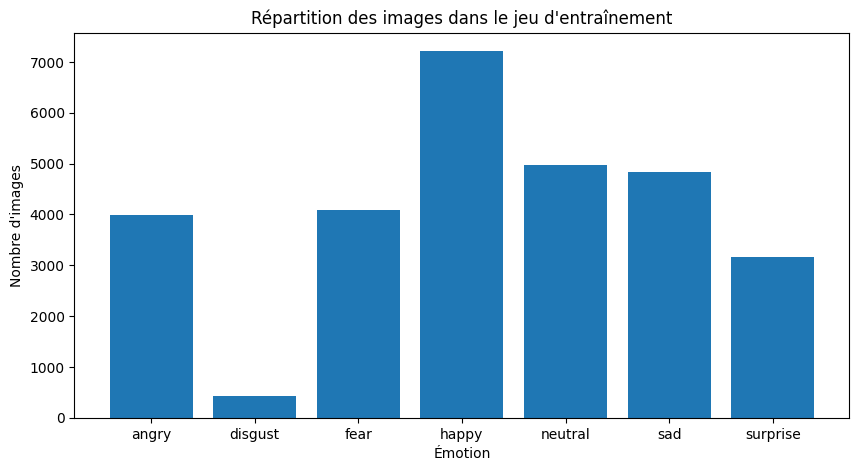

In [66]:
import matplotlib.pyplot as plt

train_counts = []

for emotion in classes:
    path = os.path.join(train_dir, emotion)
    train_counts.append(len(os.listdir(path)))

plt.figure(figsize=(10, 5))

plt.bar(classes, train_counts)

plt.title("Répartition des images dans le jeu d'entraînement")
plt.xlabel("Émotion")
plt.ylabel("Nombre d'images")

plt.show()

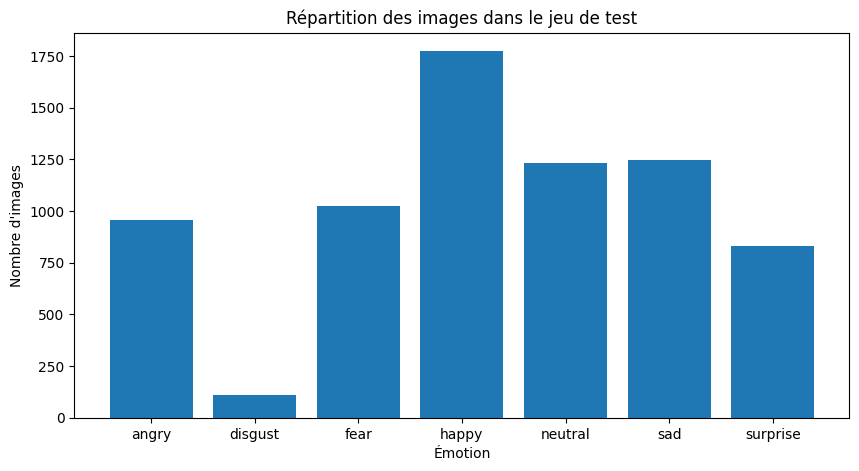

In [67]:
test_counts = []

for emotion in classes:
    path = os.path.join(test_dir, emotion)
    test_counts.append(len(os.listdir(path)))

plt.figure(figsize=(10, 5))

plt.bar(classes, test_counts)

plt.title("Répartition des images dans le jeu de test")
plt.xlabel("Émotion")
plt.ylabel("Nombre d'images")

plt.show()

In [68]:
from PIL import Image

# Prendre la première image de la première classe
emotion = classes[0]
image_name = os.listdir(os.path.join(train_dir, emotion))[0]

image_path = os.path.join(train_dir, emotion, image_name)

image = Image.open(image_path)

print("Nom :", image_name)
print("Format :", image.format)
print("Dimensions :", image.size)
print("Mode :", image.mode)

Nom : Training_25123087.jpg
Format : JPEG
Dimensions : (48, 48)
Mode : L


### Source du Dataset :  
lien : https://www.kaggle.com/datasets/aadityasinghal/facial-expression-dataset  
auteur : Aaditya Singhal  
license : https://opendatacommons.org/licenses/dbcl/1-0/

### Nombre totales d'images:  
28709 pour le train  
7159 pour le test

### Les différentes classes:  
Il y a 7 classes qui portent le nom de :  
* angry
* disgust
* fear
* happy
* neutral
* sad
* surprise

### Nombres d'images par classe:  
Le nombre d'image par classe est irrégulier, dans le cas des données d'entrainement on a :  
* angry : 3995
* disgust : 436
* fear : 4097
* happy : 7215
* neutral : 4965
* sad : 4830
* surprise : 3171

Il y a donc un déséquilibre entre les classes comme on peut le voir sur le graphique si dessus.


### Description des images :  
* Dimension : 48 * 48
* Format : image en niveau de gris / fichier jpeg

### Visualisation d'images pour chacune des classes:

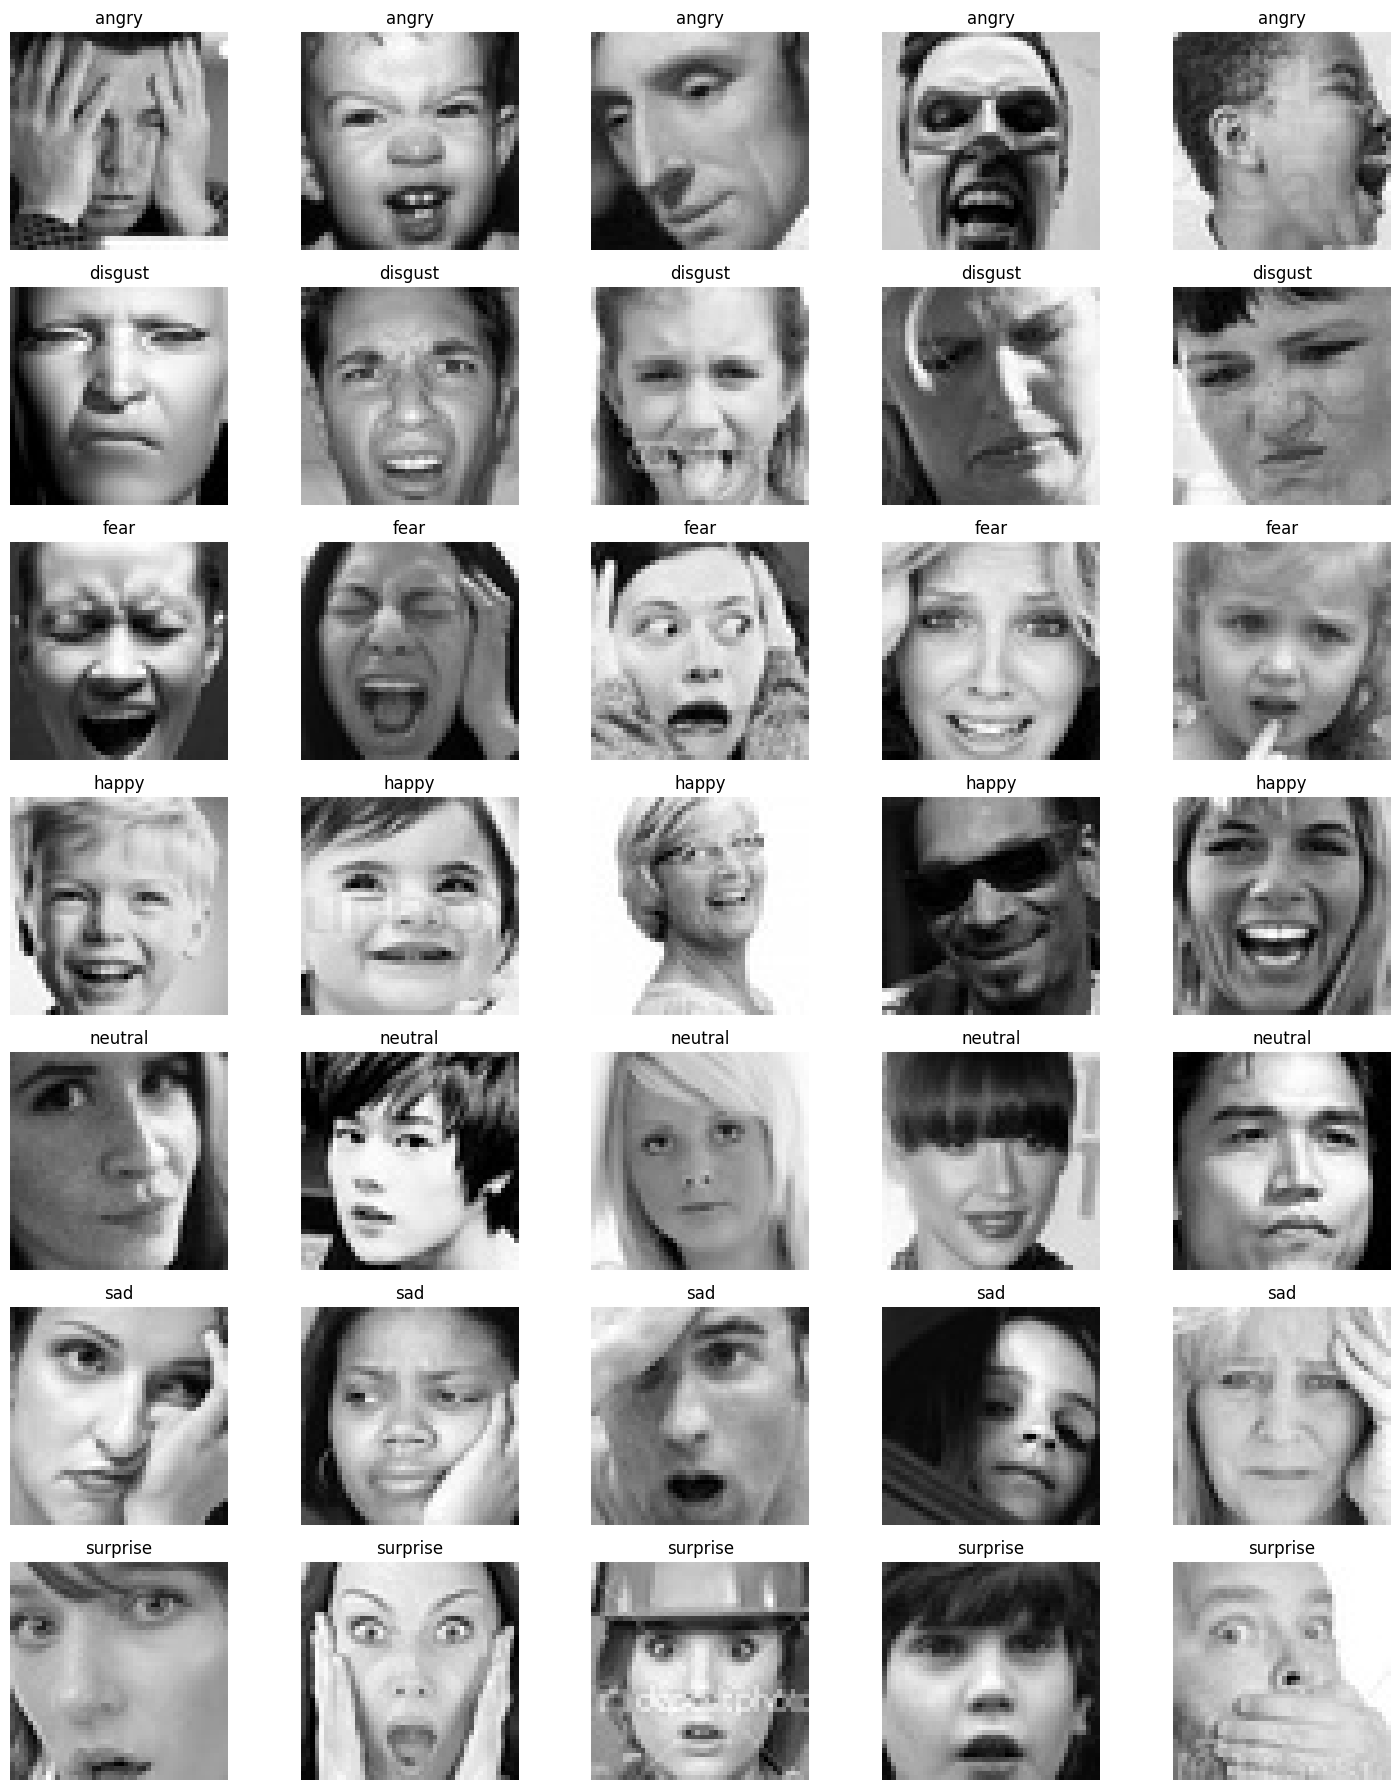

In [69]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import random

# Nombre d'images à afficher par classe
n_images = 5

plt.figure(figsize=(15, 18))

for row, emotion in enumerate(classes):

    emotion_dir = os.path.join(train_dir, emotion)
    image_names = os.listdir(emotion_dir)
    selected_images = random.sample(image_names, n_images)

    for col, image_name in enumerate(selected_images):

        image_path = os.path.join(emotion_dir, image_name)
        image = Image.open(image_path)

        position = row * n_images + col + 1

        ax = plt.subplot(len(classes), n_images, position)

        plt.imshow(image, cmap="gray")
        plt.title(emotion)
        plt.axis("off")

plt.tight_layout()
plt.show()

## Préparation des données

### Formatage des images

Cette partie permet de s'assurer que toutes les images est bien le même format et de faire des modification nécessaire par exemple réduire la taille des pixels si nécessaire pour eviter des calculs inutilement complexe.

In [70]:
from collections import Counter

# On vérifie que toutes les images soient bien en niveaux de gris
def check_image_modes(directory):
    modes = Counter()

    for root, dirs, files in os.walk(directory):
        for file in files:
            path = os.path.join(root, file)

            try:
                with Image.open(path) as img:
                    modes[img.mode] += 1
            except:
                pass

    return modes


train_modes = check_image_modes(train_dir)
test_modes = check_image_modes(test_dir)

print("Modes dans TRAIN :", train_modes)
print("Modes dans TEST  :", test_modes)

Modes dans TRAIN : Counter({'L': 28709})
Modes dans TEST  : Counter({'L': 7178})


Toutes les images sont bien en niveaux de gris

In [71]:
# Idem que précedemment pour les dimensions
def check_image_sizes(directory):
    sizes = Counter()

    for root, dirs, files in os.walk(directory):
        for file in files:
            path = os.path.join(root, file)

            try:
                with Image.open(path) as img:
                    sizes[img.size] += 1
            except:
                pass

    return sizes


train_sizes = check_image_sizes(train_dir)
test_sizes = check_image_sizes(test_dir)

print("Dimensions dans TRAIN :", train_sizes)
print("Dimensions dans TEST  :", test_sizes)

Dimensions dans TRAIN : Counter({(48, 48): 28709})
Dimensions dans TEST  : Counter({(48, 48): 7178})


Toutes les images sont de tailles 48 * 48 pixels qui est une taille acceptable (pas trop grosse), pas besoin de les redimmensionner.

In [72]:
def check_extensions(directory):
    extensions = Counter()

    for root, dirs, files in os.walk(directory):
        for file in files:
            extension = os.path.splitext(file)[1].lower()

            if extension:
                extensions[extension] += 1

    return extensions


print("Formats TRAIN :", check_extensions(train_dir))
print("Formats TEST  :", check_extensions(test_dir))

Formats TRAIN : Counter({'.jpg': 28709})
Formats TEST  : Counter({'.jpg': 7178})


Toutes les images sont bien au même format.

### Verification qu'aucune image du train ne se trouve dans le test

Cette partie permet d'éviter qu'on ne baiase accidentellement le modèle à cause de données de train qui se trouverai dans le test

In [73]:
import hashlib

def get_file_hash(path):
    md5 = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(4096), b""):
            md5.update(chunk)

    return md5.hexdigest()

In [74]:
train_hashes = {}


for root, dirs, files in os.walk(train_dir):
    for file in files:

        path = os.path.join(root, file)

        try:
            file_hash = get_file_hash(path)
            train_hashes[file_hash] = path
        except:
            pass

print("Nombre d'images analysées dans TRAIN :", len(train_hashes))

Nombre d'images analysées dans TRAIN : 27473


Si le nombre d'images analyséess ne correspond pas au nombre totales d'images c'est dû à la presence de doublons dans les données de train on s'en occupera par la suite.

In [75]:
duplicates = []

for root, dirs, files in os.walk(test_dir):
    for file in files:

        path = os.path.join(root, file)

        try:
            file_hash = get_file_hash(path)

            if file_hash in train_hashes:
                duplicates.append(
                    (train_hashes[file_hash], path)
                )
        except:
            pass

In [76]:
print("Nombre de doublons TRAIN/TEST :", len(duplicates))
print(duplicates[0])

Nombre de doublons TRAIN/TEST : 568
('/content/dataset/train/train/happy/Training_9229492.jpg', '/content/dataset/test/test/happy/PublicTest_98594654.jpg')


On peut voir qu'il y a un certain nombre d'images présentent dans le train qui se trouvent également dans le test on va donc supprimer celles présentent dans le test

In [77]:
test_files_to_remove = set()

for train_paths, test_path in duplicates:
    test_files_to_remove.add(test_path)

print("Nombre d'images uniques du test à supprimer :", len(test_files_to_remove))

Nombre d'images uniques du test à supprimer : 568


In [78]:
for path in test_files_to_remove:
    os.remove(path)

print("Suppression terminée.")

print("Nombre d'images supprimées :", len(test_files_to_remove))

Suppression terminée.
Nombre d'images supprimées : 568


In [79]:
duplicates = []

for root, dirs, files in os.walk(test_dir):
    for file in files:

        path = os.path.join(root, file)

        try:
            file_hash = get_file_hash(path)

            if file_hash in train_hashes:
                duplicates.append(
                    (train_hashes[file_hash], path)
                )
        except:
            pass
print("Nombre de doublons TRAIN/TEST :", len(duplicates))

Nombre de doublons TRAIN/TEST : 0


Tous les images présentent à la fois dans le train et le test ont bien été supprimés du test

### Constitution des ensembles train / validation / test

Dans cette partie on construit les 3 ensembles qu'on va utilser pour le projet.

On a déja nos ensemble de train et de test, il ne reste plus qu'a prendre une partie des données du train pour créer l'ensemble de validation.  
On va découper le train en 80 % de train et 20 % de validation.

In [80]:
IMG_SIZE = (48, 48)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Found 28709 files belonging to 7 classes.
Using 5741 files for validation.


In [81]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

Found 6610 files belonging to 7 classes.


### Vérification des ensembles

In [82]:
print("Classes TRAIN :", train_ds.class_names)
print("Classes VALIDATION :", val_ds.class_names)
print("Classes TEST :", test_ds.class_names)

Classes TRAIN : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Classes VALIDATION : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Classes TEST : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [83]:
for images, labels in train_ds.take(1):
    print("Shape des images :", images.shape)
    print("Shape des labels :", labels.shape)

Shape des images : (32, 48, 48, 1)
Shape des labels : (32,)


### Normalisation des pixels

Les pixels ont des valeurs comprises entre 0 et 255 pour éviter les risques d'overflow on va faire en sorte que leurs valeurs soient compris entre 0 et 1.

In [84]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

test_ds = test_ds.map(
    lambda x, y: (normalization_layer(x), y)
)

### Vérification des données

#### image avec son label

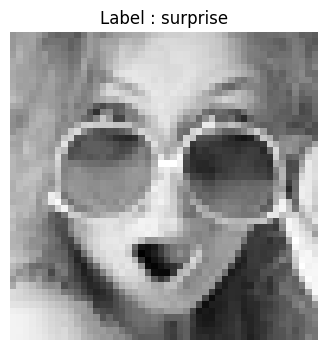

In [85]:
for images, labels in train_ds.take(1):
    image = images[0]
    label = labels[0]

    plt.figure(figsize=(4, 4))
    plt.imshow(image.numpy().squeeze(), cmap="gray")
    plt.title(f"Label : {classes[label.numpy()]}")
    plt.axis("off")
    plt.show()

#### Taille des pixels

In [86]:
for images, labels in train_ds.take(1):

    min_pixel = tf.reduce_min(images).numpy()
    max_pixel = tf.reduce_max(images).numpy()

    print("Minimum :", min_pixel)
    print("Maximum :", max_pixel)

    if min_pixel >= 0 and max_pixel <= 1:
        print("✓ Tous les pixels sont bien dans [0, 1].")
    else:
        print("✗ Attention : certains pixels sont en dehors de [0, 1].")

Minimum : 0.0
Maximum : 1.0
✓ Tous les pixels sont bien dans [0, 1].


Ici nos labels étaient déjà prêts chacune des images à pour label le dossier auquel elle appartient.

# Partie 2 - Construction d'un modèle de référence

On va construire un modèle de référence qui servira à comparer avec le CNN construit dans la partie suivante. Ce modèle aura comme architecture la suivante : Image → Flatten → Dense + activation → Dense → Softmax.

Imports

In [88]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense

On va travailler avec des images de taille 48*48 avec des niveaux de gris donc le canal choisi sera égal à 1. On veut que le résultat soit donné à travers les 7 classes d'émotions défini dans le dataset.

In [90]:
IMG_HEIGHT = 48
IMG_WIDTH = 48
CHANNELS = 1
NUM_CLASSES = len(classes)

baseline_model = Sequential([
    Flatten(input_shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS)),

    Dense(128, activation="relu"),

    Dense(NUM_CLASSES, activation="softmax")
])

baseline_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 295,943 (1.13 MB)

 Trainable params: 295,943 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

Avec Flatten, notre matrice de taille 48*48 se transforme en un vecteur de taille 2304 avec chaque composante contenant la valeur en echelle de gris du pixel. Néanmoins, on a plus la notion d'espace puisque l'image est applati en un vecteur.

Compilation du modèle

In [91]:
baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Entraînement du modèle

In [92]:
history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.2756 - loss: 1.8038 - val_accuracy: 0.2827 - val_loss: 1.7529
Epoch 2/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.3211 - loss: 1.7174 - val_accuracy: 0.3390 - val_loss: 1.7032
Epoch 3/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.3345 - loss: 1.6905 - val_accuracy: 0.3393 - val_loss: 1.6860
Epoch 4/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.3400 - loss: 1.6763 - val_accuracy: 0.3440 - val_loss: 1.6929
Epoch 5/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.3433 - loss: 1.6610 - val_accuracy: 0.3557 - val_loss: 1.6608
Epoch 6/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3496 - loss: 1.6541 - val_accuracy: 0.3231 - val_loss: 1.6895
Epoch 7/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.3590 - loss: 1.6409 - val_accuracy: 0.3625 - val_loss: 1.6431
Epoch 8/10
718/718 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.3554 - loss: 1.6426 - val_ac

Visualisation de l'apprentissage du modèle

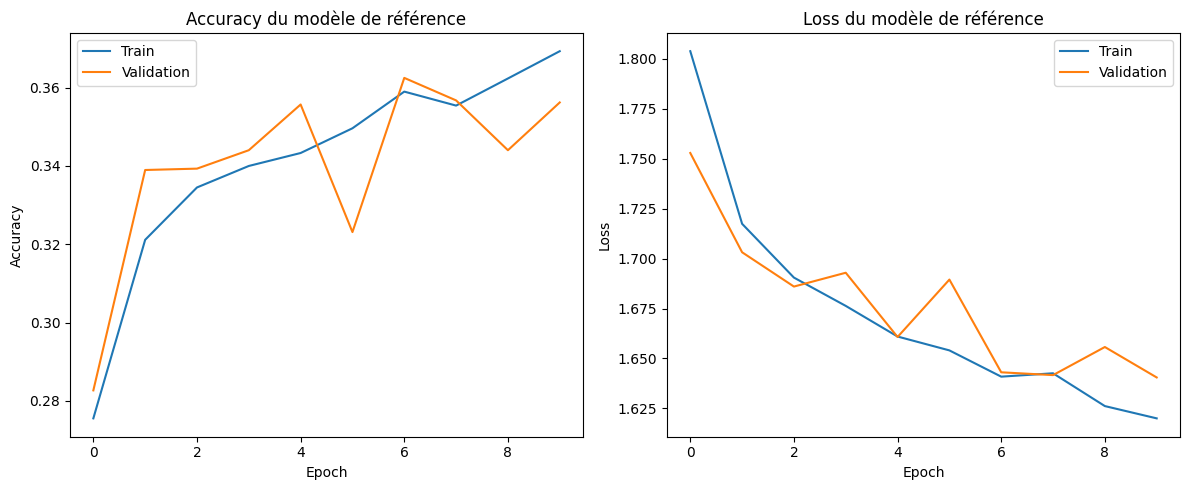

In [93]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.plot(history_baseline.history["accuracy"], label="Train")
plt.plot(history_baseline.history["val_accuracy"], label="Validation")

plt.title("Accuracy du modèle de référence")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)

plt.plot(history_baseline.history["loss"], label="Train")
plt.plot(history_baseline.history["val_loss"], label="Validation")

plt.title("Loss du modèle de référence")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

Evaluation du modèle

In [94]:
test_loss, test_accuracy = baseline_model.evaluate(test_ds)

print(f"Loss sur le test : {test_loss:.4f}")
print(f"Accuracy sur le test : {test_accuracy:.4f}")

207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3526 - loss: 1.6442
Loss sur le test : 1.6442
Accuracy sur le test : 0.3526


On obtiens une accuracy de 35% sur les données du modèle ce qui est insuffisant pour determiner correctement l'émotion d'une image. On voit que c'est un modèle pas adapté à ce genre d'usage car l'image n'est pas traité correctement

Sortie Softmax

In [95]:
import numpy as np

for images, labels in test_ds.take(1):

    predictions = baseline_model.predict(images)

    image_index = 0

    print("Vrai label :", classes[labels[image_index].numpy()])
    print("\nProbabilités prédites :")

    for class_name, probability in zip(
        classes,
        predictions[image_index]
    ):
        print(f"{class_name:10s} : {probability:.4f}")

    predicted_class = np.argmax(predictions[image_index])

    print(
        "\nClasse prédite :",
        classes[predicted_class]
    )

    break

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Vrai label : happy

Probabilités prédites :
angry      : 0.1733
disgust    : 0.0095
fear       : 0.1789
happy      : 0.2488
neutral    : 0.0462
sad        : 0.1384
surprise   : 0.2050

Classe prédite : happy


Dans le cas d'une image, avec SoftMax, on va selectionner la classe avec la probabilité la plus élevée et ce résultat va donner l'émotion décrite pas l'image.

Question du cours :  

La fonction de perte permet de mesurer l'écart entre les classes prédites et les classes réelles du dataset. Lorsqu'elle est faible, le modèle fait moins d'erreurs et si elle est élevée, le modèle se trompe beaucoup.

La propagation vers l'avant permet à la donnée d'entrée, en l'occurance l'image dans notre cas, de traverser toutes les couches du système.

La rétropropagation permet de calculer les nouveaux biais et poids du réseau pour affiner les résultats du modèle.
